In [1]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.path import Path

In [2]:
#PARAMETROS QUE TOCAR:

GLOBAL_file = "helio1.csv"  #El archivo de turno. Me han molado hidrogeno 3 y 4, helio 1 y 2 (en unos se ve absorcion y los otros son muy limpios) y neon 1. La del mercurio tambien mola
GLOBAL_reference_wavelength = "heliumreference.csv" #La referencia de las lambdas esperadas
GLOBAL_Prominence = 0.01 #La "grandeza" mínima que tiene que tener un pico para que lo registre. Para el helio me ha gustado 0.05
GLOBAL_relheight = 0.1 #Cuanto error le asigna a cada pico, en función de lo puntiagudo que sea. Para el helio me ha gustado 0.1
GLOBAL_numticks = 10 #Cuantas subdivisiones en la longitud de onda tienen los plots. Para el helio 10 hace que haya un tick cada 50 nm

SPECTRUM_gamma = 0.4 #Cambia el brillo de las lineas espectrales. Muy alto y no se ve un pijo, mu bajo y se ve t_odo el arcoiris. El 0.4-0.5 va bien para el helio1

PLOT_gamma = 0.025 #Cambia el brillo del gradiente de colores del plot. Va mano a mano con el smoothsigma. Este si lo podeis tocar si quereis que el borde tenga mas contraste con el relleno.
PLOT_smoothsigma = 10 #Cambia lo smooth que es el gradiente de colores del plot. Yo no lo tocaría mucho a no ser que se vean saltos de colores o toqueis el anterior


#si tocais algo que no está aquí y peta no me hago responsable

In [3]:
df = pd.read_csv(GLOBAL_file, delimiter=",", skiprows=20)
wavelengths = df["nm"].to_numpy()
intensities = df["Value"].to_numpy()

refdf = pd.read_csv(GLOBAL_reference_wavelength, header=None)
referenceWavelengths = refdf[0]

print(np.max(intensities))

1.0


In [4]:
peakIndex, peakData = scipy.signal.find_peaks(intensities, prominence=GLOBAL_Prominence)
widths, width_heights, left_ips, right_ips = scipy.signal.peak_widths(intensities, peakIndex, rel_height=GLOBAL_relheight)

sampleSize = (max(wavelengths) - min(wavelengths)) / len(wavelengths)
errors = widths*sampleSize

#def sample_to_frequency(x):
#    return x*(max(wavelengths) - min(wavelengths))/len(wavelengths) + min(wavelengths)
#print(sample_to_frequency(0))
#print(frequency[left_ips])
#peakError = frequency[peaks[1].get("right_bases")] - frequency[peaks[1].get("left_bases")]

In [5]:
def wavelength_to_rgb(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    Additionally alpha value set to 0.5 outside range
    '''
    wavelength = float(wavelength)
    if wavelength >= 380 and wavelength <= 750:
        A = 1.
    else:
        A = 0.5
    if wavelength < 380:
        wavelength = 380.
    if wavelength > 750:
        wavelength = 750.
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 <= wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 <= wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 <= wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 <= wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 <= wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    return (R, G, B, A)


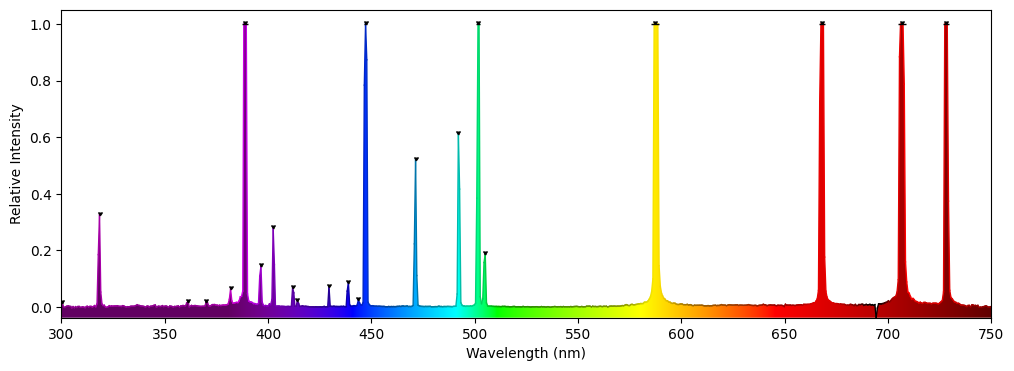

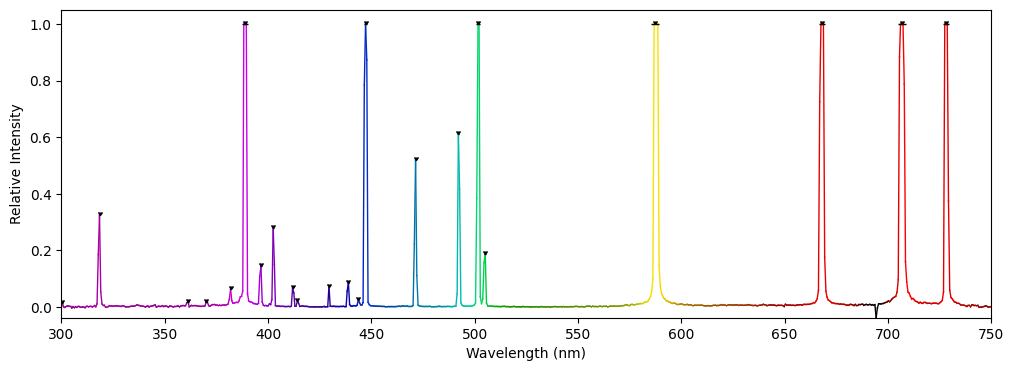

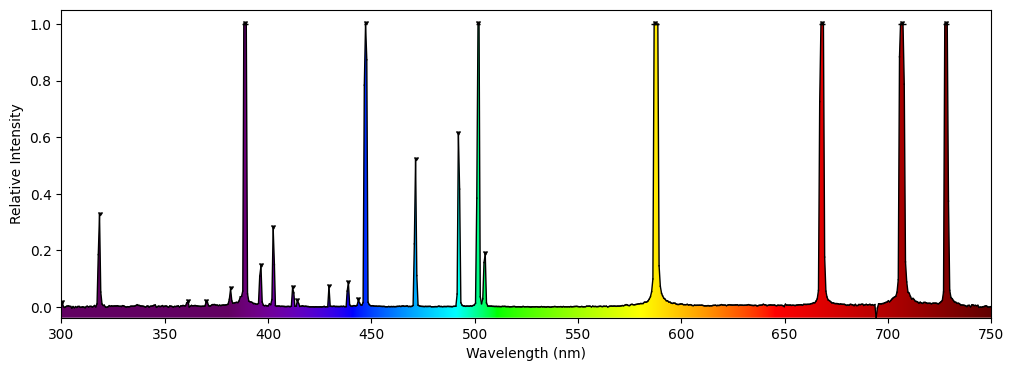

In [6]:
def plot_spectrum_clip_fill(
    wavelengths, intensities, wavelength_to_rgb, gamma=2.2, smooth_sigma=1.0, height=200, line_width=2.0, fill_lower=None, fill_enabled=True, line_color=None, ax=None
):
    """
    Plot spectrum with line + optional fill using clip-path.
    Can plot directly onto an existing axes if ax is provided.
    """

    # Determine vertical bounds
    if fill_lower is None:
        ymin = np.min(intensities)
    else:
        ymin = float(fill_lower)
    ymax = intensities.max() * 1.05

    # Create axes if not provided
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
        created_fig = True

    # Background fill (optional)
    if fill_enabled:
        rgb_bg = np.array([wavelength_to_rgb(w)[:3] for w in wavelengths])
        img = np.repeat(rgb_bg[np.newaxis, :, :], height, axis=0)

        verts = np.column_stack([wavelengths, intensities])
        poly = np.concatenate([
            [[wavelengths[0], ymin]],
            verts,
            [[wavelengths[-1], ymin]],
            [[wavelengths[0], ymin]]
        ])

        codes = [Path.MOVETO] + [Path.LINETO]*len(wavelengths) + [Path.LINETO, Path.CLOSEPOLY]
        clip_path = Path(poly, codes)

        im = ax.imshow(
            img,
            extent=[wavelengths.min(), wavelengths.max(), ymin, ymax],
            aspect='auto',
            origin='lower'
        )
        im.set_clip_path(clip_path, transform=ax.transData)

    # Intensity-modulated line
    if line_color is None:
        inten_norm = mcolors.Normalize(vmin=intensities.min(), vmax=intensities.max())(intensities)
        bright = inten_norm**gamma
        if smooth_sigma > 0:
            bright = scipy.ndimage.gaussian_filter1d(bright, smooth_sigma)
        bright = (bright - bright.min()) / (bright.max() - bright.min() + 1e-12)

        base_rgb = np.array([wavelength_to_rgb(w)[:3] for w in wavelengths])
        hsv = mcolors.rgb_to_hsv(base_rgb)
        hsv[:, 2] = bright
        rgb_line = mcolors.hsv_to_rgb(hsv)

        for i in range(len(wavelengths)-1):
            ax.plot(wavelengths[i:i+2], intensities[i:i+2], color=rgb_line[i], lw=line_width)
    else:
        for i in range(len(wavelengths)-1):
            ax.plot(wavelengths[i:i+2], intensities[i:i+2], color=line_color, lw=line_width)

    # Axes formatting
    ax.set_xlim(wavelengths.min(), wavelengths.max())
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Relative Intensity")

    tick_locations = np.linspace(wavelengths.min(), wavelengths.max(), GLOBAL_numticks)

    # Align bottom axes ticks with middle ticks
    ax.set_xticks(tick_locations)
    tick_labels = ["{:.0f}".format(x) for x in tick_locations]
    ax.set_xticklabels(tick_labels)

    if created_fig:
        return fig, ax
    else:
        return ax

fig, ax = plot_spectrum_clip_fill(wavelengths, intensities, wavelength_to_rgb, smooth_sigma= PLOT_smoothsigma, gamma = PLOT_gamma, line_width=1, fill_enabled=True)
ax.errorbar(wavelengths[peakIndex], intensities[peakIndex], marker =7, markersize= 3, color ="#000000", xerr = errors, capsize = 0, elinewidth=1, linestyle ="None", ecolor ="#000000", barsabove=False)#b73b00
plt.savefig("plotrellenodecolor.png",dpi = 300)
plt.show()

fig, ax = plot_spectrum_clip_fill(wavelengths, intensities, wavelength_to_rgb,smooth_sigma = PLOT_smoothsigma, gamma = PLOT_gamma, line_width=1, fill_enabled=False)
ax.errorbar(wavelengths[peakIndex], intensities[peakIndex], marker =7, markersize= 3, color ="#000000", xerr = errors, capsize = 0, elinewidth=1, linestyle ="None", ecolor ="#000000", barsabove=False)#b73b00
plt.savefig("plotsinrelleno.png",dpi = 300)
plt.show()

fig, ax = plot_spectrum_clip_fill(wavelengths, intensities, wavelength_to_rgb, smooth_sigma= PLOT_smoothsigma, gamma = PLOT_gamma, line_width=1, fill_enabled=True, line_color="#000000")
ax.errorbar(wavelengths[peakIndex], intensities[peakIndex], marker =7, markersize= 3, color ="#000000", xerr = errors, capsize = 0, elinewidth=1, linestyle ="None", ecolor ="#000000", barsabove=False)#b73b00
plt.savefig("plotrellenoenbandw.png",dpi = 300)
plt.show()



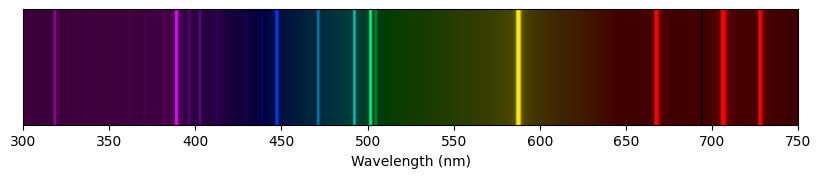

In [7]:
def make_wavelength_intensity_cmap(
        wavelengths, intensities, wavelength_to_rgb,
        light_on_high=True, gamma=2.2, smooth_sigma=1.0
):
    """
    Build a colormap where:
    - hue comes from wavelength_to_rgb(w)
    - brightness comes from intensity**gamma
    - brightness is smoothed to avoid abrupt jumps around sharp peaks
    """

    # Normalize intensities to [0,1]
    inten_norm = mcolors.Normalize(vmin=np.min(intensities),
                                   vmax=np.max(intensities))(intensities)

    # Apply gamma for contrast
    bright = inten_norm ** gamma

    # Smooth brightness to soften transitions
    if smooth_sigma > 0:
        bright = scipy.ndimage.gaussian_filter1d(bright, sigma=smooth_sigma)

    # Re-normalize brightness after smoothing
    bright = (bright - bright.min()) / (bright.max() - bright.min() + 1e-12)

    # Convert wavelength to RGB (strip alpha)
    base_rgb = np.array([tuple(wavelength_to_rgb(w))[:3] for w in wavelengths])

    # Convert to HSV to modify brightness only
    hsv = mcolors.rgb_to_hsv(base_rgb)

    if light_on_high:
        hsv[:, 2] = bright
    else:
        hsv[:, 2] = 1 - bright

    new_rgb = mcolors.hsv_to_rgb(hsv)
    return mcolors.ListedColormap(new_rgb)


def render_spectrum_image(
        wavelengths, intensities, wavelength_to_rgb,
        image_height=100, light_on_high=True, gamma=2.2,
        x_min=None, x_max=None, num_display_samples=1000,
        ax=None
):
    """
    Render a horizontal spectrum image.
    Can render directly onto an existing axes if ax is provided.
    """

    if x_min is None:
        x_min = wavelengths.min()
    if x_max is None:
        x_max = wavelengths.max()

    wl_display = np.linspace(x_min, x_max, num_display_samples)
    inten_display = np.interp(wl_display, wavelengths, intensities)

    cmap_image = make_wavelength_intensity_cmap(
        wl_display, inten_display, wavelength_to_rgb,
        light_on_high=light_on_high, gamma=gamma, smooth_sigma=0
    )

    img = np.tile(np.arange(num_display_samples), (image_height, 1))

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 1.5))
        created_fig = True

    ax.imshow(img, cmap=cmap_image, aspect='auto', extent=[x_min, x_max, 0, 1])
    ax.set_yticks([])

    tick_locations = np.linspace(wavelengths.min(), wavelengths.max(), GLOBAL_numticks)

    # Align bottom axes ticks with middle ticks
    ax.set_xticks(tick_locations)
    tick_labels = ["{:.0f}".format(x) for x in tick_locations]
    ax.set_xticklabels(tick_labels)

    ax.set_xlabel("Wavelength (nm)")

    if created_fig:
        return fig, ax
    else:
        return ax


fig, ax = render_spectrum_image(wavelengths, intensities, wavelength_to_rgb, image_height=100, gamma = SPECTRUM_gamma)
plt.savefig("espectrochuliguay.png",dpi = 300, bbox_inches='tight')
plt.show()


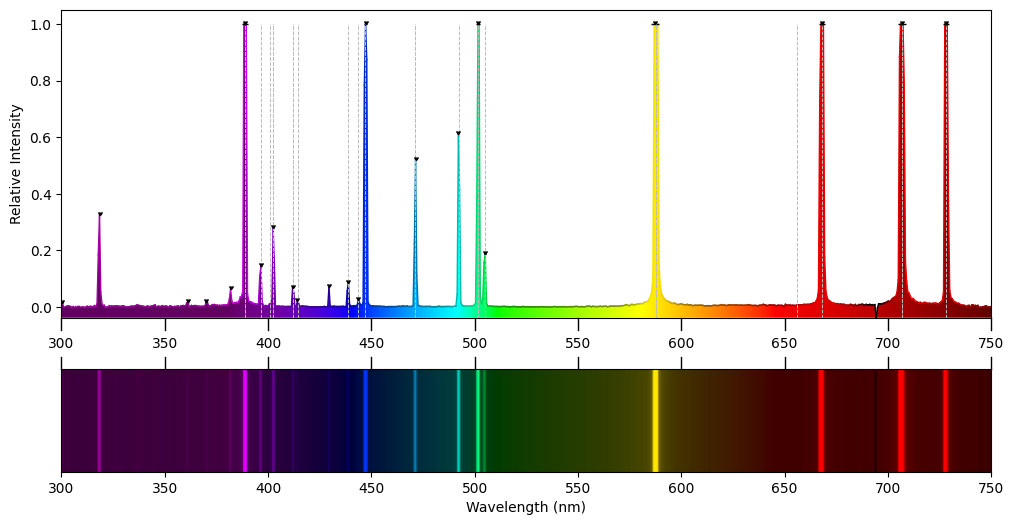

In [8]:
def plot_spectrum_custom_heights_gammas(
        wavelengths,
        intensities,
        wavelength_to_rgb,
        gamma_top=2.2,
        gamma_bottom=2.2,
        smooth_sigma=1.0,
        line_width=2.0,
        fill_lower=None,
        fill_enabled=True,
        line_color=None,
        figsize=(12, 4),
        top_height=4,
        bottom_height=1,
        vertical_spacing=0.25,
        num_ticks=5,
        tick_format="{:.0f}"
):
    """
    Plot combined spectrum figure:
    - Top: intensity vs wavelength line plot
    - Bottom: horizontal spectrum image
    - Middle: tick labels centered, with two short ticks per x-location
      (one touching the top plot, one touching the bottom plot)
    - Bottom axes ticks aligned with middle ticks
    - Independent top/bottom heights and gamma parameters
    """

    ymin = np.min(intensities) if fill_lower is None else float(fill_lower)
    ymax = intensities.max() * 1.05

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[top_height, bottom_height], hspace=vertical_spacing)

    # --- Top: line plot ---
    ax_line = fig.add_subplot(gs[0])
    if fill_enabled:
        rgb_bg = np.array([wavelength_to_rgb(w)[:3] for w in wavelengths])
        img = np.repeat(rgb_bg[np.newaxis, :, :], 50, axis=0)
        verts = np.column_stack([wavelengths, intensities])
        poly = np.concatenate([
            [[wavelengths[0], ymin]],
            verts,
            [[wavelengths[-1], ymin]],
            [[wavelengths[0], ymin]]
        ])
        codes = [Path.MOVETO] + [Path.LINETO]*len(wavelengths) + [Path.LINETO, Path.CLOSEPOLY]
        clip_path = Path(poly, codes)
        im = ax_line.imshow(
            img,
            extent=[wavelengths.min(), wavelengths.max(), ymin, ymax],
            aspect='auto',
            origin='lower'
        )
        im.set_clip_path(clip_path, transform=ax_line.transData)

    if line_color is None:
        inten_norm = mcolors.Normalize(vmin=intensities.min(), vmax=intensities.max())(intensities)
        bright = inten_norm ** gamma_top
        if smooth_sigma > 0:
            bright = scipy.ndimage.gaussian_filter1d(bright, smooth_sigma)
        bright = (bright - bright.min()) / (bright.max() - bright.min() + 1e-12)
        base_rgb = np.array([wavelength_to_rgb(w)[:3] for w in wavelengths])
        hsv = mcolors.rgb_to_hsv(base_rgb)
        hsv[:, 2] = bright
        rgb_line = mcolors.hsv_to_rgb(hsv)
        for i in range(len(wavelengths)-1):
            ax_line.plot(wavelengths[i:i+2], intensities[i:i+2], color=rgb_line[i], lw=line_width)
    else:
        for i in range(len(wavelengths)-1):
            ax_line.plot(wavelengths[i:i+2], intensities[i:i+2], color=line_color, lw=line_width)

    ax_line.set_xlim(wavelengths.min(), wavelengths.max())
    ax_line.set_ylim(ymin, ymax)
    ax_line.set_ylabel("Relative Intensity")
    ax_line.tick_params(axis='x', bottom=False, top=False, labelbottom=False)

    # --- Bottom: spectrum image ---
    ax_img = fig.add_subplot(gs[1], sharex=ax_line)
    wl_display = np.linspace(wavelengths.min(), wavelengths.max(), 1000)
    inten_display = np.interp(wl_display, wavelengths, intensities)
    inten_norm = mcolors.Normalize(vmin=np.min(inten_display), vmax=np.max(inten_display))(inten_display)
    bright = inten_norm ** gamma_bottom
    bright = (bright - bright.min()) / (bright.max() - bright.min() + 1e-12)
    base_rgb = np.array([wavelength_to_rgb(w)[:3] for w in wl_display])
    hsv = mcolors.rgb_to_hsv(base_rgb)
    hsv[:, 2] = bright
    cmap_image = mcolors.ListedColormap(mcolors.hsv_to_rgb(hsv))
    img_data = np.tile(np.arange(len(wl_display)), (20, 1))
    ax_img.imshow(img_data, cmap=cmap_image, aspect='auto', extent=[wl_display.min(), wl_display.max(), 0, 1])
    ax_img.set_yticks([])
    ax_img.set_xlabel("Wavelength (nm)")

    # --- Middle ticks and labels ---
    tick_locations = np.linspace(wavelengths.min(), wavelengths.max(), num_ticks)

    # Align bottom axes ticks with middle ticks
    ax_img.set_xticks(tick_locations)
    tick_labels = [tick_format.format(x) for x in tick_locations]
    ax_img.set_xticklabels(tick_labels)
    ax_img.tick_params(axis='x', labelbottom=True)

    top_pos = ax_line.get_position()
    bottom_pos = ax_img.get_position()
    middle_y = (top_pos.y0 + bottom_pos.y1) / 2  # center of the space between axes

    for x in tick_locations:
        x_fig = ax_line.transData.transform((x, 0))[0]
        x_fig_rel = (x_fig - fig.bbox.x0) / fig.bbox.width

        # Tick from top plot downwards
        fig.lines.append(plt.Line2D([x_fig_rel, x_fig_rel], [top_pos.y0, top_pos.y0 - 0.02],
                                    transform=fig.transFigure, color='k', lw=1))
        # Tick from bottom plot upwards
        fig.lines.append(plt.Line2D([x_fig_rel, x_fig_rel], [bottom_pos.y1, bottom_pos.y1 + 0.02],
                                    transform=fig.transFigure, color='k', lw=1))
        # Label in the middle
        fig.text(x_fig_rel, middle_y, tick_format.format(x), ha='center', va='center', fontsize=10)

    return fig, (ax_line, ax_img)

fig, (ax_plot, ax_spec) = plot_spectrum_custom_heights_gammas(
    wavelengths=wavelengths,
    intensities=intensities,
    wavelength_to_rgb=wavelength_to_rgb,
    line_width=1,
    fill_enabled=True,
    line_color=None,
    gamma_bottom = SPECTRUM_gamma,
    vertical_spacing=0.25,
    top_height=9,
    bottom_height = 3,
    num_ticks = GLOBAL_numticks,
    figsize = (12,6),
    gamma_top = PLOT_gamma,
    smooth_sigma= PLOT_smoothsigma
)

ax_plot.errorbar(wavelengths[peakIndex], intensities[peakIndex], marker =7, markersize= 3, color ="#000000", xerr = errors, capsize = 0, elinewidth=1, linestyle ="None", ecolor ="#000000", barsabove=False)#b73b00

for wl in referenceWavelengths:
    ax_plot.vlines(wl, min(intensities), max(intensities), ls = "--", color = "#BBBBBB", lw = .7)

plt.savefig("bestplotever.png", dpi = 500, bbox_inches = "tight")
plt.show()

In [9]:
peakIntensities = intensities[peakIndex]
peakErrors = widths*sampleSize/2
peakWavelengths = wavelengths[peakIndex]

print(peakIntensities)
print(peakErrors)
print(peakWavelengths)

outputdf = pd.DataFrame()
outputdf["Wavelength"] = peakWavelengths
outputdf["WavelengthError"] = peakErrors
outputdf["Intensity"] = peakIntensities

outputdf.to_excel("longitudesdeonda.xlsx", sheet_name = "Datos")


[0.01412 0.3263  0.01936 0.01847 0.06402 1.      0.1441  0.2782  0.06842
 0.02147 0.07235 0.08606 0.02464 1.      0.521   0.6113  1.      0.1872
 1.      1.      1.      1.     ]
[0.06272157 0.1036007  0.15206614 0.29098526 0.07581625 0.65205203
 0.14392843 0.09516211 0.13894164 0.09811614 0.05969381 0.1143965
 0.08333509 0.37016076 0.08884889 0.12388616 0.37360781 0.20255172
 0.95194957 0.73333169 0.98201115 0.66796472]
[300.5 318.5 361.3 370.1 381.9 388.9 396.6 402.5 411.9 414.2 429.5 438.9
 443.7 447.2 471.4 492.1 501.6 505.1 587.4 668.1 706.6 728. ]
